### This notebook is an example of creating the window on the disk and further analysis, including creating activity matrix, and visualization of mapping the windows back to the original Cell shape

In [23]:
import os
import sys
import numpy as np
sys.path.append("../utils/")
from load_objects import load_uwnrap_objects
import importlib
import plot_functions
importlib.reload(plot_functions)
from run_stack import window_all_TF, calculate_window_intensity
from plot_functions import plot_intensity_origin
import split_window2D
importlib.reload(split_window2D)
from split_window2D import UnwrapWindow


In [59]:
# load unwrap pickle files
folder_path = "/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/data/Collins_Data_Processed/step4_2015_paper_registration_stilltesting/2013-05-24_Gradient_protocol_Cell1/unwrap2D_pickle"
unwrap_img_stack, unwrap_params_stack, unwrap_mask_stack,_,_,_,_ = load_uwnrap_objects(folder_path)

In [9]:
raster_size = 256 # parameter for sampling on the disk, increase to sample more data points, must match with the one set in the previous steps
unwrap_save = False
THETA_NUM = 60  # how many windows in each layer
R_NUM = 12      # how many layers  
border_pad = 32

In [4]:
# window all the frames and create bioactivity matrix for each layer
# initiate window object
window_stack = window_all_TF(unwrap_img_stack, unwrap_params_stack, raster_size = raster_size, border_pad = 32)

# all_intensity, all_edge_xy, all_masks = calculate_window_intensity(window_stack, 
#                                                             r_num = R_NUM,
#                                                             theta_num = THETA_NUM,
#                                                             layer_n = 1)

In [45]:
save_path = "/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/data/Collins_Data_Processed/step4_2015_paper_registration_stilltesting/2013-05-24_Gradient_protocol_Cell1"
# all frame share the same uv_mask
window = UnwrapWindow(unwrap_img_stack[0], 
                        unwrap_params_stack[0], 
                        raster_size=raster_size, 
                        border_pad=border_pad)
_, _, segment_masks, _ = window.split_window(R_NUM, THETA_NUM)

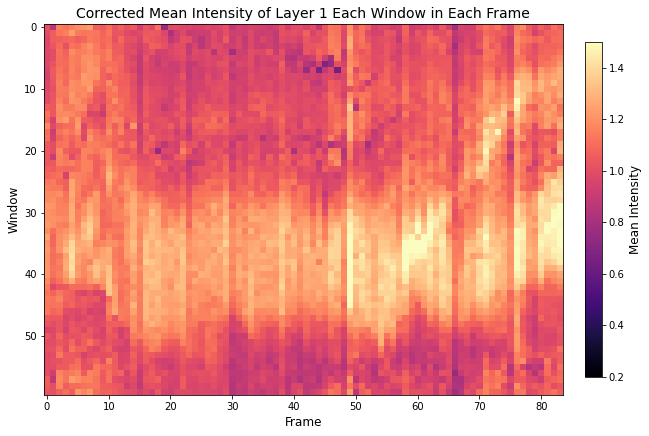

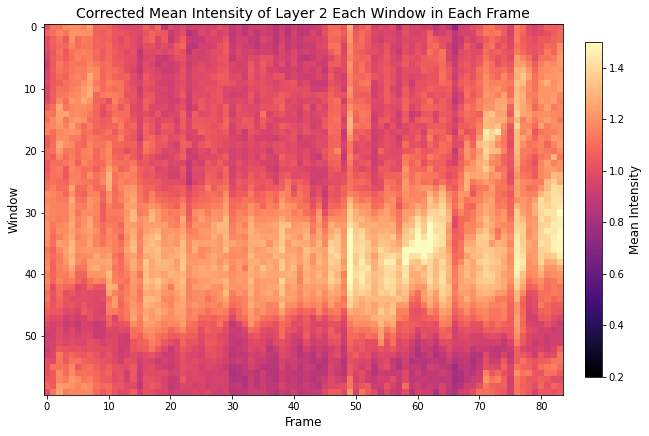

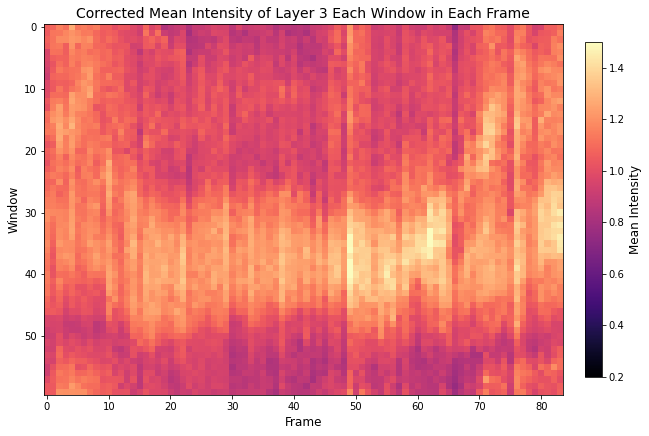

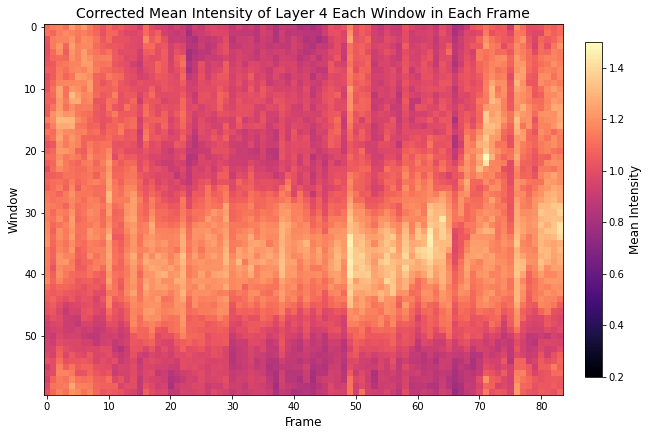

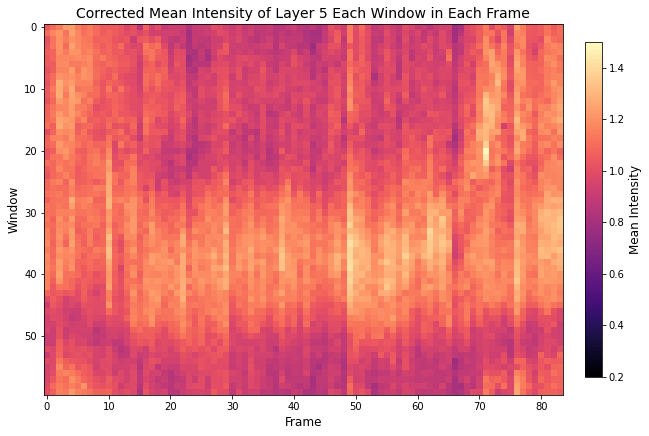

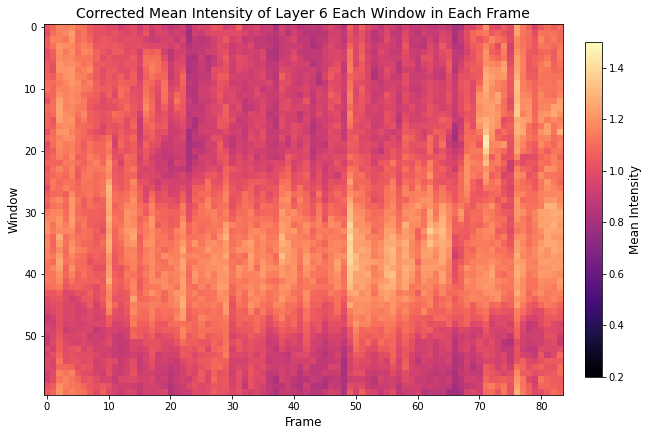

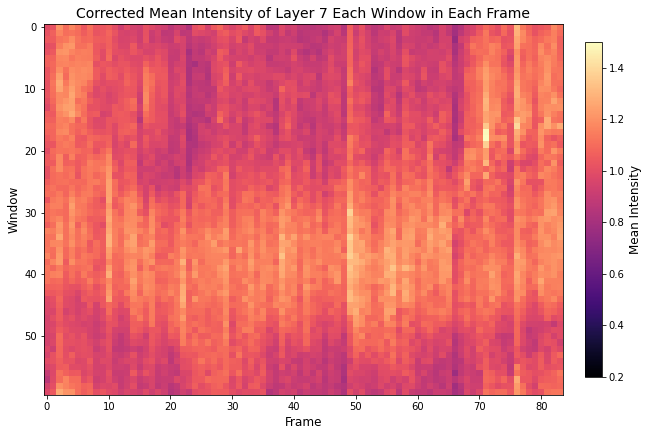

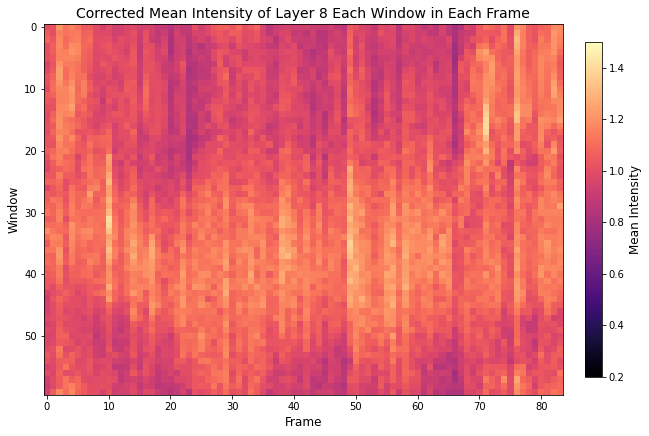

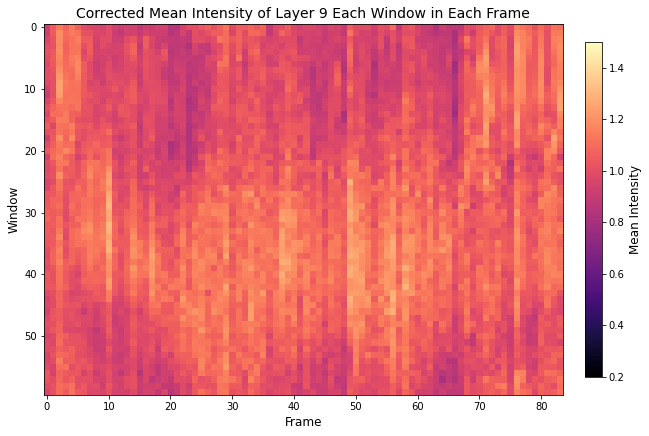

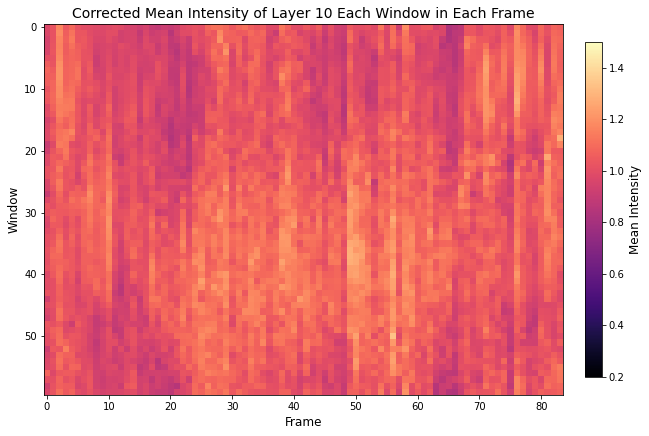

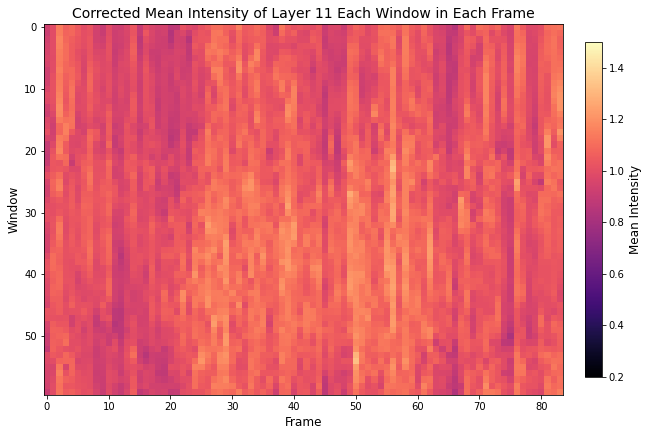

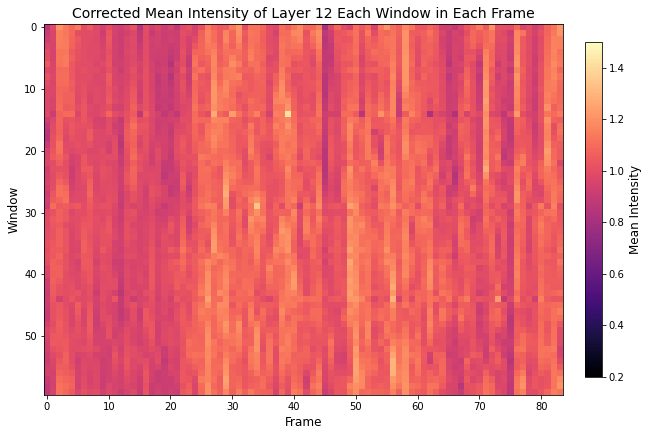

In [76]:
# window intensity
import plot_intensity_origin
importlib.reload(plot_intensity_origin)
from plot_intensity_origin import plot_intensity_origin

save_path = "/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/data/Collins_Data_Processed/step4_2015_paper_registration_stilltesting/2013-05-24_Gradient_protocol_Cell1"

intensity_layers = []
Rac1_savepath = os.path.join(save_path, "intensity")
os.makedirs(Rac1_savepath, exist_ok=True)
for i in range(1, R_NUM + 1):
    intensity = plot_intensity_origin(segment_masks, unwrap_params_stack, unwrap_img_stack, unwrap_mask_stack, save_path = Rac1_savepath,radius = raster_size*2-1,  layer = i, theta_num = THETA_NUM,vmin=0.2, vmax=1.5,cmap='magma',interpolation=None)
    intensity_layers.append(intensity)
intensity_layers = np.array(intensity_layers)
